In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Customer_Churn_Prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [9]:
num_cols=df.select_dtypes(exclude="object").columns
cat_cols=df.select_dtypes(include="object").columns

In [10]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

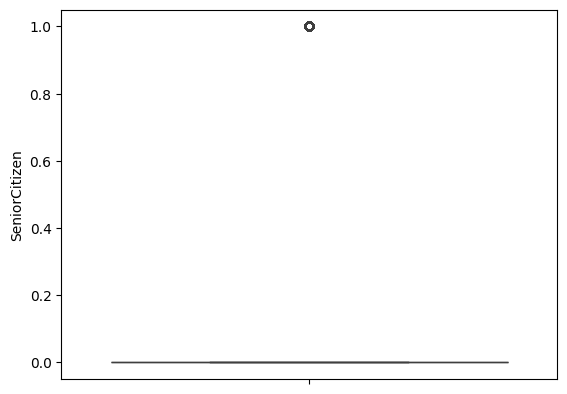

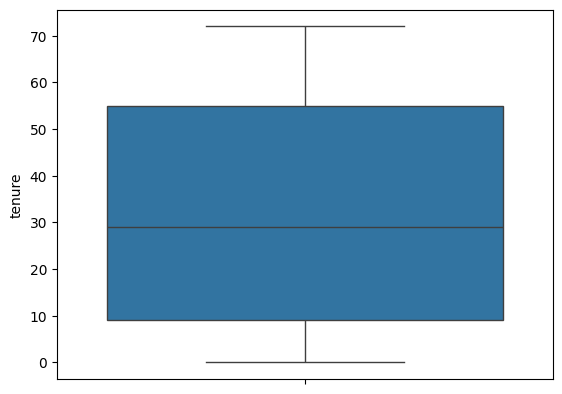

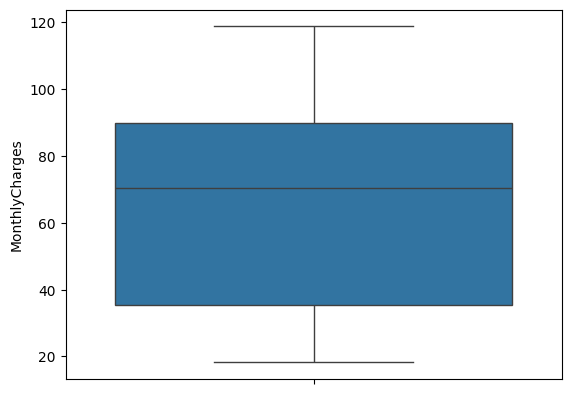

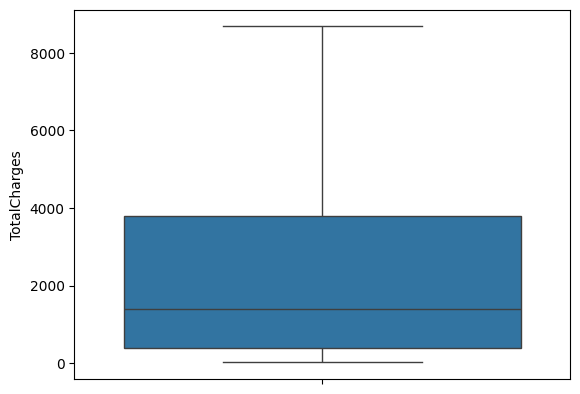

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in num_cols:
    sns.boxplot(df[col])
    plt.show()


In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

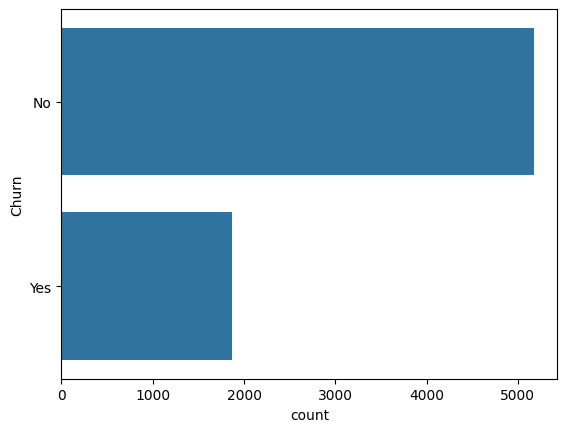

In [13]:
sns.countplot(df["Churn"])
plt.show()

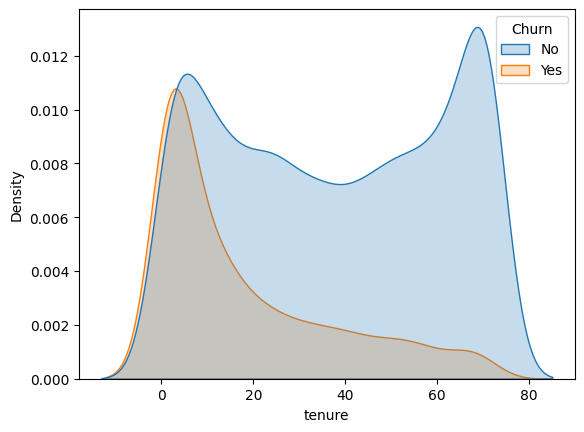

In [14]:
sns.kdeplot(x=df["tenure"],hue=df["Churn"],fill=True)
plt.show()

Customers with lower tenure are more likely to churn, indicating that new customers have a higher risk of leaving early,possibly because they have not yet developed loyalty or fully experienced the service value.

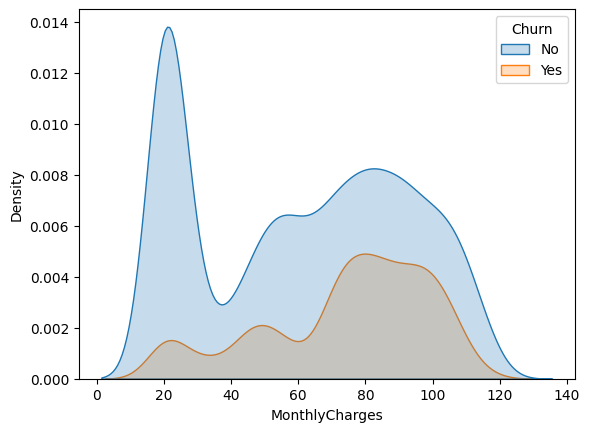

In [15]:
sns.kdeplot(x=df["MonthlyCharges"],hue=df["Churn"],fill=True)
plt.show()

Customers with higher monthly charges show a higher tendency to churn, suggesting pricing may be a key factor in customer retention.

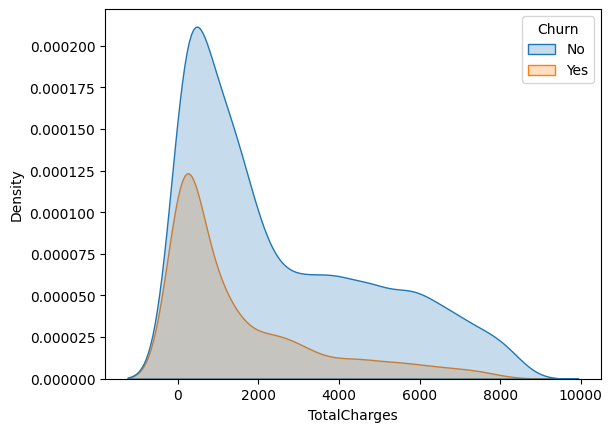

In [16]:
sns.kdeplot(x=df["TotalCharges"],hue=df["Churn"],fill=True)
plt.show()

Customers with higher total charges are show higher tendency to churn, so overall total charges reduction can help in customer retention.

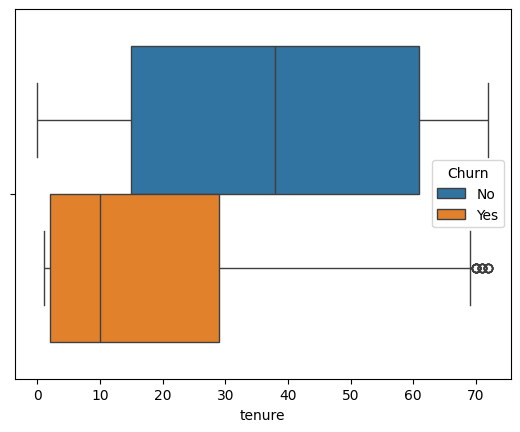

In [17]:
sns.boxplot(x=df["tenure"],hue=df["Churn"])
plt.show()

Customers with lower tenure are significantly more likely to churn, whereas customers who stay longer tend to remain loyal. This indicates that churn is highest in the early stages of the customer lifecycle.

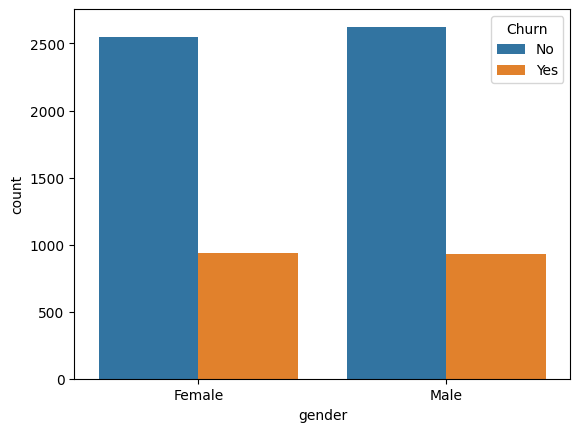

In [18]:
sns.countplot(x="gender",hue="Churn",data=df)
plt.show()

Female customers show a slightly higher tendency to churn compared to male customers; however, the difference is not substantial. This suggests that while gender may have a minor influence on churn, it is likely not a primary driving factor, and other features such as tenure, contract type, or pricing may play a more significant role.

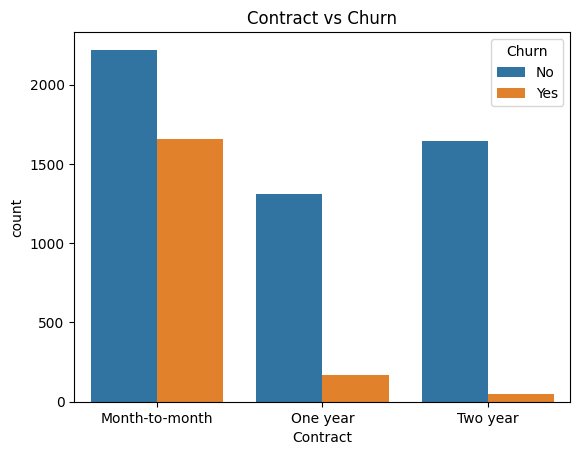

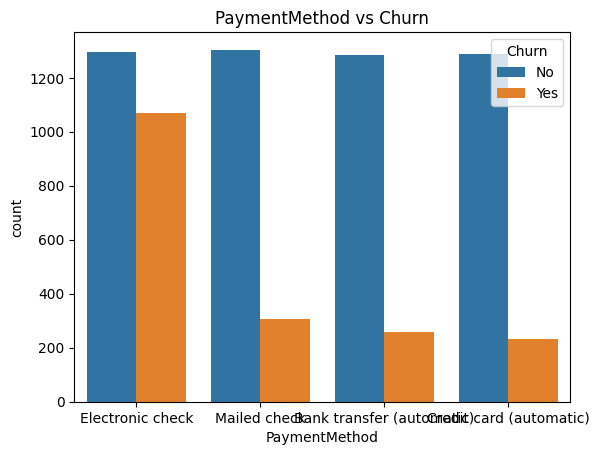

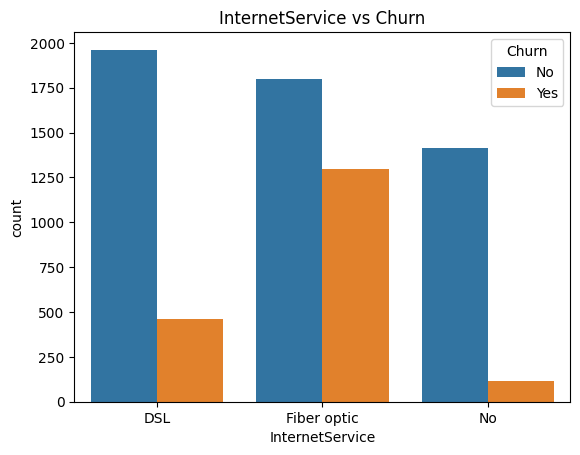

In [27]:
col=["Contract","PaymentMethod","InternetService"]
for i in col:
    sns.countplot(x=i,hue="Churn",data=df)
    plt.title(f"{i} vs Churn")
    plt.show()